# DeepDash — Transformer World Model Training (Colab GPU)

**Runtime → Change runtime type → GPU** before running.

Trains the Transformer world model on pre-tokenized FSQ episode data.
The model predicts next-frame tokens (64 visual + 1 death/alive status) given K context frames + actions.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import subprocess, sys

REPO_URL = "https://github.com/FlorentTariolle/DeepDash.git"
REPO_DIR = "/content/DeepDash"
DRIVE_DIR = "/content/drive/MyDrive/DeepDash"

# Clone repo (skip if already present)
![ -d {REPO_DIR} ] || git clone {REPO_URL} {REPO_DIR}

# Install dependencies
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                       "torch", "numpy", "matplotlib"])

sys.path.insert(0, REPO_DIR)

# Create Drive dir for persistent outputs (checkpoints, logs)
import os
os.makedirs(f"{DRIVE_DIR}/checkpoints", exist_ok=True)

Mounted at /content/drive
Cloning into '/content/DeepDash'...
remote: Enumerating objects: 1582, done.
remote: Counting objects: 100% (148/148), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 1582 (delta 85), reused 111 (delta 55), pack-reused 1434 (from 4)
Receiving objects: 100% (1582/1582), 714.61 MiB | 17.59 MiB/s, done.
Resolving deltas: 100% (660/660), done.
Updating files: 100% (711/711), done.


## 2. Configuration

In [ ]:
import types

cfg = types.SimpleNamespace(
    # Paths — episodes from repo, checkpoints saved to Drive for persistence
    episodes_dir=f"{REPO_DIR}/data/episodes",
    fsq_checkpoint=f"{REPO_DIR}/checkpoints/fsq_best.pt",
    checkpoint_dir=f"{DRIVE_DIR}/checkpoints",
    local_checkpoint_dir="/content/checkpoints",

    # Architecture
    vocab_size=1000,
    tokens_per_frame=64,
    embed_dim=128,
    n_heads=4,
    n_layers=6,
    context_frames=8,
    dropout=0.1,

    # Training
    epochs=200,
    batch_size=256,
    lr=1e-3,
    weight_decay=0.05,
    cpc_weight=0.1,
    token_noise=0.10,
    label_smoothing=0.1,
    patience=30,
    drive_save_every=5,  # sync to Drive every N epochs
    death_oversample=15,  # repeat death-frame samples this many times

    # Data
    val_ratio=0.1,
    seed=42,

    # Resume from checkpoint
    resume=False,
)

print(f"Episodes dir: {cfg.episodes_dir}")
print(f"FSQ checkpoint: {cfg.fsq_checkpoint}")
print(f"Output checkpoint dir: {cfg.checkpoint_dir}")
print(f"Local checkpoint dir: {cfg.local_checkpoint_dir} (synced to Drive every {cfg.drive_save_every} epochs)")

## 3. Tokenize episodes

Encodes raw `frames.npy` through the frozen FSQ-VAE to produce `tokens.npy`. Skips episodes that are already tokenized.

In [3]:
from pathlib import Path
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

from deepdash.fsq import FSQVAE

fsq_model = FSQVAE(levels=[8, 5, 5, 5]).to(device)
fsq_model.load_state_dict(torch.load(cfg.fsq_checkpoint, map_location=device, weights_only=True))
fsq_model.eval()
print(f"Loaded FSQ-VAE from {cfg.fsq_checkpoint}")

episodes_dir = Path(cfg.episodes_dir)
episodes = sorted(ep for ep in episodes_dir.glob("*") if (ep / "frames.npy").exists())
print(f"Found {len(episodes)} episodes with frames")

tokenize_batch = 128
total_tokenized = 0

with torch.no_grad():
    for ep in episodes:
        if (ep / "tokens.npy").exists():
            continue  # already tokenized

        frames = np.load(ep / "frames.npy")  # (T, 64, 64) uint8
        T = len(frames)
        all_tokens = []

        for i in range(0, T, tokenize_batch):
            batch = frames[i:i + tokenize_batch]
            x = torch.from_numpy(batch).float().unsqueeze(1).to(device) / 255.0
            indices = fsq_model.encode(x)  # (B, 8, 8)
            all_tokens.append(indices.cpu().reshape(-1, 64).numpy())

        tokens = np.concatenate(all_tokens, axis=0).astype(np.uint16)
        np.save(ep / "tokens.npy", tokens)
        total_tokenized += 1
        print(f"  {ep.name}: {T} frames -> {tokens.shape}")

if total_tokenized == 0:
    print("All episodes already tokenized.")
else:
    print(f"Tokenized {total_tokenized} new episodes.")

del fsq_model
torch.cuda.empty_cache()

Device: cuda
Loaded FSQ-VAE from /content/DeepDash/checkpoints/fsq_best.pt
Found 332 episodes with frames
  ep_0001: 11 frames -> (11, 64)
  ep_0002: 114 frames -> (114, 64)
  ep_0003: 64 frames -> (64, 64)
  ep_0004: 16 frames -> (16, 64)
  ep_0005: 83 frames -> (83, 64)
  ep_0007: 60 frames -> (60, 64)
  ep_0009: 40 frames -> (40, 64)
  ep_0010: 47 frames -> (47, 64)
  ep_0013: 20 frames -> (20, 64)
  ep_0015: 20 frames -> (20, 64)
  ep_0016: 28 frames -> (28, 64)
  ep_0018: 20 frames -> (20, 64)
  ep_0021: 48 frames -> (48, 64)
  ep_0022: 6 frames -> (6, 64)
  ep_0023: 38 frames -> (38, 64)
  ep_0024: 53 frames -> (53, 64)
  ep_0025: 88 frames -> (88, 64)
  ep_0026: 140 frames -> (140, 64)
  ep_0027: 48 frames -> (48, 64)
  ep_0028: 60 frames -> (60, 64)
  ep_0029: 52 frames -> (52, 64)
  ep_0031: 17 frames -> (17, 64)
  ep_0033: 33 frames -> (33, 64)
  ep_0036: 9 frames -> (9, 64)
  ep_0037: 99 frames -> (99, 64)
  ep_0038: 6 frames -> (6, 64)
  ep_0039: 32 frames -> (32, 64)
  ep_

## 4. Load tokenized episodes & build samples

In [ ]:
import json
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(cfg.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(cfg.seed)
    torch.backends.cudnn.benchmark = True

# Discover tokenized episodes
all_episodes = sorted(ep for ep in episodes_dir.glob("*")
                      if (ep / "tokens.npy").exists())

assert len(all_episodes) > 0, (
    f"No tokenized episodes found in {episodes_dir}. "
    "Make sure step 3 (tokenization) ran successfully."
)

rng = np.random.default_rng(cfg.seed)
indices = rng.permutation(len(all_episodes))
val_count = max(1, int(len(all_episodes) * cfg.val_ratio))
val_episodes = {all_episodes[i].name for i in indices[:val_count]}

print(f"Total tokenized episodes: {len(all_episodes)}")
print(f"Val episodes: {val_count}, Train episodes: {len(all_episodes) - val_count}")

K = cfg.context_frames
TPF = cfg.tokens_per_frame
train_frames, train_actions, train_levels = [], [], []
val_frames, val_actions, val_levels = [], [], []
n_deaths = 0

for ep in all_episodes:
    tokens = np.load(ep / "tokens.npy")   # (T, TPF)
    actions = np.load(ep / "actions.npy")  # (T,)
    T = len(tokens)
    if T < K + 1:
        continue

    level_id = 0
    meta_path = ep / "metadata.json"
    if meta_path.exists():
        meta = json.loads(meta_path.read_text())
        level_id = meta.get("level", 1) - 1

    is_clear = "clear" in ep.name
    is_val = ep.name in val_episodes
    f_list = val_frames if is_val else train_frames
    a_list = val_actions if is_val else train_actions
    l_list = val_levels if is_val else train_levels

    for i in range(T - K):
        frame_window = tokens[i:i + K + 1].astype(np.int64)
        action_window = actions[i:i + K].astype(np.int64)

        status = np.full((K + 1, 1), 0, dtype=np.int64)
        is_death_frame = (not is_clear) and (i + K == T - 1)
        if is_death_frame:
            status[K] = 1
        n_deaths += int(is_death_frame)

        frame_with_status = np.concatenate([frame_window, status], axis=1)
        repeats = cfg.death_oversample if is_death_frame else 1
        for _ in range(repeats):
            f_list.append(frame_with_status)
            a_list.append(action_window)
            l_list.append(level_id)

total_samples = len(train_frames) + len(val_frames)
print(f"Train samples: {len(train_frames)}, Val samples: {len(val_frames)}")
if total_samples > 0:
    print(f"Death frames: {n_deaths} unique, {n_deaths * cfg.death_oversample} after {cfg.death_oversample}x oversample ({100*n_deaths*cfg.death_oversample/total_samples:.1f}%)")

# Pre-stack into contiguous tensors (avoids per-item numpy->torch overhead)
print("Stacking into tensors...")
train_frames_t = torch.from_numpy(np.stack(train_frames))
train_actions_t = torch.from_numpy(np.stack(train_actions))
train_levels_t = torch.tensor(train_levels, dtype=torch.long)
val_frames_t = torch.from_numpy(np.stack(val_frames))
val_actions_t = torch.from_numpy(np.stack(val_actions))
val_levels_t = torch.tensor(val_levels, dtype=torch.long)

# Free the lists
del train_frames, train_actions, train_levels
del val_frames, val_actions, val_levels

print(f"Train tensor: {train_frames_t.shape}, Val tensor: {val_frames_t.shape}")

## 5. Model & DataLoaders

In [5]:
from deepdash.world_model import WorldModel

model = WorldModel(
    vocab_size=cfg.vocab_size,
    n_actions=2,
    embed_dim=cfg.embed_dim,
    n_heads=cfg.n_heads,
    n_layers=cfg.n_layers,
    context_frames=cfg.context_frames,
    dropout=cfg.dropout,
    tokens_per_frame=cfg.tokens_per_frame,
).to(device)

# Remap status column upfront: 0 -> ALIVE_TOKEN, 1 -> DEATH_TOKEN
for t in (train_frames_t, val_frames_t):
    status = t[:, :, -1]
    status[status == 0] = model.ALIVE_TOKEN
    status[status == 1] = model.DEATH_TOKEN

train_dataset = TensorDataset(train_frames_t, train_actions_t, train_levels_t)
val_dataset = TensorDataset(val_frames_t, val_actions_t, val_levels_t)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size,
                          shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size,
                        shuffle=False, num_workers=0, pin_memory=True)

# torch.compile fuses ops for faster execution (first epoch is slower due to tracing)
# CPC loss has dynamic loops so we disable fullgraph to allow graph breaks there
try:
    model = torch.compile(model)
    print("torch.compile enabled")
except Exception as e:
    print(f"torch.compile not available, running eager: {e}")

param_count = sum(p.numel() for p in model.parameters())
_m = model._orig_mod if hasattr(model, "_orig_mod") else model
print(f"Model parameters: {param_count:,}")
print(f"Context: {cfg.context_frames} frames, Sequence length: {_m.seq_len}")
print(f"Vocab: {cfg.vocab_size} visual + 2 status = {_m.full_vocab_size}")
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

torch.compile enabled
Model parameters: 1,410,112
Context: 4 frames, Sequence length: 329
Vocab: 1000 visual + 2 status = 1002
Train batches: 76, Val batches: 12


In [6]:
!cd {REPO_DIR} && git pull

Already up to date.


## 6. Training

In [ ]:
import csv
import time
import shutil

# Ensure model is compiled (no-op if already compiled from model cell)
if not hasattr(model, "_orig_mod"):
    try:
        model = torch.compile(model)
        print("torch.compile enabled (was not compiled)")
    except Exception as e:
        print(f"torch.compile not available: {e}")

# Helper to access model attrs whether compiled or not
def _unwrap(model):
    return model._orig_mod if hasattr(model, "_orig_mod") else model

def _save_state(path, model, optimizer, scheduler, scaler, epoch, best_val_loss):
    torch.save({
        "epoch": epoch,
        "model": _unwrap(model).state_dict(),
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "best_val_loss": best_val_loss,
    }, path / "transformer_state.pt")

def _sync_to_drive(local_dir, drive_dir):
    """Copy all checkpoints from local to Drive."""
    for f in Path(local_dir).glob("transformer_*.pt"):
        shutil.copy2(f, drive_dir / f.name)
    # Also copy the log
    log = Path(local_dir) / "transformer_log.csv"
    if log.exists():
        shutil.copy2(log, drive_dir / log.name)

# ── train / val epoch functions (AMP + non-blocking transfers) ───────────────

def train_epoch(model, loader, optimizer, scaler, cpc_weight, device,
                token_noise=0.0, label_smoothing=0.0):
    model.train()
    m = _unwrap(model)
    tpf = m.tokens_per_frame
    vocab = m.full_vocab_size
    vs = m.vocab_size
    total_loss, total_correct, total_tokens = 0, 0, 0
    total_death_correct, total_death_samples = 0, 0
    total_cpc_loss = 0.0

    for frame_tokens, actions, level_ids in loader:
        frame_tokens = frame_tokens.to(device, non_blocking=True)
        actions = actions.to(device, non_blocking=True)
        level_ids = level_ids.to(device, non_blocking=True)

        target = frame_tokens[:, -1]  # (B, 65)

        # Scheduled sampling: corrupt context visual tokens
        if token_noise > 0:
            ctx = frame_tokens[:, :-1].clone()
            visual = ctx[:, :, :tpf]
            mask = torch.rand_like(visual, dtype=torch.float) < token_noise
            random_tokens = torch.randint(0, vs, visual.shape, device=device)
            visual = torch.where(mask, random_tokens, visual)
            ctx[:, :, :tpf] = visual
            frame_tokens = torch.cat([ctx, frame_tokens[:, -1:]], dim=1)

        with torch.autocast("cuda", dtype=torch.float16):
            logits, cpc_loss = model(frame_tokens, actions, level_ids)
            token_loss = torch.nn.functional.cross_entropy(
                logits.reshape(-1, vocab),
                target.reshape(-1),
                label_smoothing=label_smoothing,
            )
            loss = token_loss + cpc_weight * cpc_loss

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = frame_tokens.size(0)
        with torch.no_grad():
            visual_preds = logits[:, :tpf].argmax(dim=-1)
            visual_target = target[:, :tpf]
            total_correct += (visual_preds == visual_target).sum().item()
            total_tokens += bs * tpf
            total_loss += token_loss.item() * bs

            status_target = target[:, tpf]
            status_pred = logits[:, tpf].argmax(dim=-1)
            total_death_correct += (status_pred == status_target).sum().item()
            total_death_samples += bs
            total_cpc_loss += cpc_loss.item() * bs

    return (total_loss / total_death_samples, total_correct / total_tokens,
            total_death_correct / total_death_samples,
            total_cpc_loss / total_death_samples)


@torch.no_grad()
def val_epoch(model, loader, device):
    model.eval()
    m = _unwrap(model)
    tpf = m.tokens_per_frame
    vocab = m.full_vocab_size
    total_loss, total_correct, total_tokens = 0, 0, 0
    total_death_correct, total_death_samples = 0, 0

    for frame_tokens, actions, level_ids in loader:
        frame_tokens = frame_tokens.to(device, non_blocking=True)
        actions = actions.to(device, non_blocking=True)
        level_ids = level_ids.to(device, non_blocking=True)

        target = frame_tokens[:, -1]

        with torch.autocast("cuda", dtype=torch.float16):
            logits, _ = model(frame_tokens, actions, level_ids)

        visual_target = target[:, :tpf]
        visual_logits = logits[:, :tpf]
        token_loss = torch.nn.functional.cross_entropy(
            visual_logits.reshape(-1, vocab),
            visual_target.reshape(-1),
        )

        bs = frame_tokens.size(0)
        total_loss += token_loss.item() * bs * tpf
        total_correct += (visual_logits.argmax(dim=-1) == visual_target).sum().item()
        total_tokens += bs * tpf

        status_target = target[:, tpf]
        status_pred = logits[:, tpf].argmax(dim=-1)
        total_death_correct += (status_pred == status_target).sum().item()
        total_death_samples += bs

    return (total_loss / total_tokens, total_correct / total_tokens,
            total_death_correct / total_death_samples)


# ── Optimizer, scheduler, checkpoint resume ──────────────────────────────────

optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr,
                              weight_decay=cfg.weight_decay)
scaler = torch.GradScaler("cuda")

local_dir = Path(cfg.local_checkpoint_dir)
local_dir.mkdir(parents=True, exist_ok=True)
ckpt_dir = Path(cfg.checkpoint_dir)
ckpt_dir.mkdir(parents=True, exist_ok=True)

start_epoch = 1
best_val_loss = float("inf")

if cfg.resume:
    # Try local first, fall back to Drive
    resume_path = local_dir / "transformer_state.pt"
    if not resume_path.exists():
        resume_path = ckpt_dir / "transformer_state.pt"
    if resume_path.exists():
        state = torch.load(resume_path, map_location=device, weights_only=False)
        _unwrap(model).load_state_dict(state["model"])
        optimizer.load_state_dict(state["optimizer"])
        if "scaler" in state:
            scaler.load_state_dict(state["scaler"])
        start_epoch = state["epoch"] + 1
        best_val_loss = state["best_val_loss"]
        print(f"Resumed from epoch {state['epoch']} (best val loss: {best_val_loss:.4f})")
    else:
        print("No checkpoint found, starting fresh.")

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=cfg.epochs, eta_min=1e-5,
    last_epoch=start_epoch - 2 if start_epoch > 1 else -1)

# CSV log (local) — append if last logged epoch matches resume point
log_path = local_dir / "transformer_log.csv"
append = False
if log_path.exists() and start_epoch > 1:
    with open(log_path) as f:
        rows = list(csv.reader(f))
        if rows:
            try:
                last_logged = int(rows[-1][0])
                append = last_logged == start_epoch - 1
            except (ValueError, IndexError):
                pass
if append:
    log_file = open(log_path, "a", newline="")
else:
    log_file = open(log_path, "w", newline="")
log_writer = csv.writer(log_file)
if not append:
    log_writer.writerow(["epoch", "train_loss", "train_acc", "train_death_acc",
                         "train_cpc", "val_loss", "val_acc", "val_death_acc",
                         "lr", "time_s"])

# ── Training loop ────────────────────────────────────────────────────────────

LOCAL_SAVE_EVERY = 5  # save local checkpoint every N epochs (avoids CUDA sync overhead)
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
patience_counter = 0

print("First epoch will be slower due to torch.compile tracing...")
try:
    for epoch in range(start_epoch, cfg.epochs + 1):
        t0 = time.time()
        train_loss, train_acc, train_death_acc, train_cpc = train_epoch(
            model, train_loader, optimizer, scaler,
            cfg.cpc_weight, device, token_noise=cfg.token_noise,
            label_smoothing=cfg.label_smoothing)
        val_loss, val_acc, val_death_acc = val_epoch(model, val_loader, device)
        scheduler.step()
        dt = time.time() - t0
        lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch:3d}/{cfg.epochs} ({dt:.1f}s) | "
            f"Train: loss={train_loss:.4f} acc={train_acc:.3f} "
            f"death={train_death_acc:.3f} cpc={train_cpc:.3f} | "
            f"Val: loss={val_loss:.4f} acc={val_acc:.3f} death={val_death_acc:.3f} | "
            f"LR: {lr:.1e}"
        )

        log_writer.writerow([
            epoch, f"{train_loss:.6f}", f"{train_acc:.4f}", f"{train_death_acc:.4f}",
            f"{train_cpc:.4f}", f"{val_loss:.6f}", f"{val_acc:.4f}",
            f"{val_death_acc:.4f}", f"{lr:.1e}", f"{dt:.1f}"
        ])
        log_file.flush()

        # Save best model immediately (small — just model weights)
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(_unwrap(model).state_dict(), local_dir / "transformer_best.pt")
        else:
            patience_counter += 1
            if cfg.patience > 0 and patience_counter >= cfg.patience:
                print(f"\nEarly stopping: val loss did not improve for {cfg.patience} epochs.")
                break

        # Save full state (model+optimizer+scaler) less frequently to avoid CUDA sync overhead
        if epoch % LOCAL_SAVE_EVERY == 0:
            _save_state(local_dir, model, optimizer, scheduler, scaler, epoch, best_val_loss)

        # Sync to Drive periodically
        if epoch % cfg.drive_save_every == 0:
            _sync_to_drive(local_dir, ckpt_dir)
            print(f"  [Synced to Drive]")

        # Defragment CUDA memory periodically
        if epoch % 2 == 0:
            torch.cuda.empty_cache()

except KeyboardInterrupt:
    print("\nInterrupted — saving checkpoint...")
    _save_state(local_dir, model, optimizer, scheduler, scaler, epoch, best_val_loss)

log_file.close()
torch.save(_unwrap(model).state_dict(), local_dir / "transformer_final.pt")

# Final sync to Drive
_sync_to_drive(local_dir, ckpt_dir)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")
print(f"Checkpoints synced to {ckpt_dir}/")

## 7. Training curves

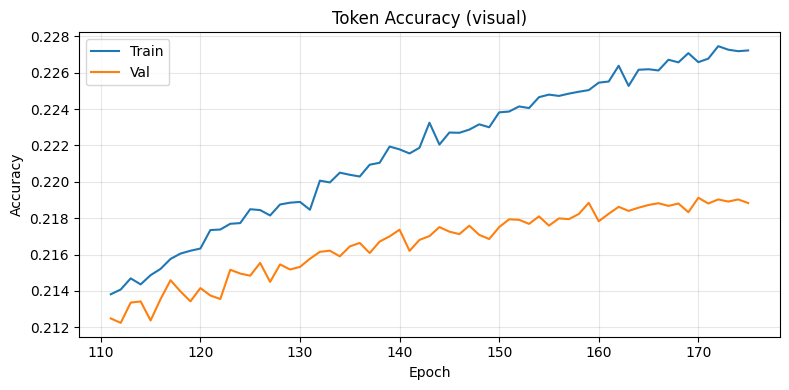

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))

epochs_range = range(start_epoch, start_epoch + len(history["train_acc"]))

ax.plot(epochs_range, history["train_acc"], label="Train")
ax.plot(epochs_range, history["val_acc"], label="Val")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.set_title("Token Accuracy (visual)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Download data

In [17]:
from google.colab import files
files.download("/content/drive/MyDrive/DeepDash/checkpoints/transformer_final.pt")
files.download("/content/drive/MyDrive/DeepDash/checkpoints/transformer_state.pt")
files.download("/content/drive/MyDrive/DeepDash/checkpoints/transformer_best.pt")
files.download("/content/drive/MyDrive/DeepDash/checkpoints/transformer_log.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>